## Loop Approach

In [ ]:
# Loop apprach

import numpy as np
import matplotlib.pyplot as plt
import time # Imported to compare compiling time for different parameters

# Buffon's Needle simulation parameters
num_needles = 100000
t = 20
len_needle = 10  

# Initializing counters
total = 0
intersecting = 0

# Function to check if a needle intersects with a grid line
def intersects(x, angle):
    # Calculate the x-coordinates of both ends of the needle
    x1 = x - (len_needle / 2) * np.cos(angle)
    x2 = x + (len_needle / 2) * np.cos(angle)

    # Check if either end of the needle crosses a line
    line1 = np.floor(x1 / t)
    line2 = np.floor(x2 / t)

    return line1 != line2

# Record start time
start_time = time.time()

# Buffon's Needle simulation
for i in range(num_needles):
    angle = np.random.uniform(0, np.pi)
    x = np.random.uniform(0, 600)

    if intersects(x, angle):
        intersecting += 1

# Estimate pi
probability = intersecting / num_needles
if probability > 0:
    pi_estimate = (2 * len_needle) / (probability * t)
else:
    pi_estimate = float('inf')  # Handle the case where probability is 0
    
# Record end time
end_time = time.time()

# Print the estimated value of pi and the time taken
print('Probability:', probability)
print('Num needles:', num_needles)
print(f'Estimated value of pi: {pi_estimate:.9f}')
print(f'Time taken: {end_time - start_time:.6f} seconds')


Probability: 0.31492
Num needles: 100000
Estimated value of pi: 3.175409628
Time taken: 0.712424 seconds


## W Array Method

In [3]:
# Array Method

import numpy as np
import time

# Buffon's Needle simulation parameters
num_needles = 1000  # Increased for a larger sample size
t = 20  # Adjusted for grid spacing
len_needle = 10  # Adjusted to be smaller than the spacing

# Record start time
start_time = time.time()

# Generate random angles and positions
angles = np.random.uniform(0, np.pi, num_needles)
x = np.random.uniform(0, 600, num_needles)

# Calculate x-coordinates of both ends of the needles
x1 = x - (len_needle / 2) * np.cos(angles)
x2 = x + (len_needle / 2) * np.cos(angles)

# Check for intersections
line1 = np.floor(x1 / t)
line2 = np.floor(x2 / t)
intersections = np.sum(line1 != line2)

# Estimate pi
probability = intersections / num_needles
pi_estimate = (2 * len_needle) / (probability * t) 

# Record end time
end_time = time.time()

# Print the estimated value of pi and the time taken
print('Probability:', probability)
print('Num needles:', num_needles)
print(f'Estimated value of pi: {pi_estimate:.9f}')
print(f'Time taken: {end_time - start_time:.6f} seconds')

# Error Estimation (Optional)
# You can run the above simulation multiple times and calculate the standard deviation of the pi estimates.
#Probability: 0.31827274666666666
#Num needles: 450000000
#Estimated value of pi: 3.141959249
#Time taken: 14.668038 seconds

#Probability: 0.318310138
#Num needles: 500000000
#Estimated value of pi: 3.141590168
#Time taken: 16.803287 seconds

#Probability: 0.31830932
#Num needles: 900000000
#Estimated value of pi: 3.141598242
#Time taken: 29.023767 seconds

Probability: 0.301
Num needles: 1000
Estimated value of pi: 3.322259136
Time taken: 0.000670 seconds


## Some results from array method

## Some interestring exlpaination from our dear friend

## Box plot to show distrubution of results depending on needle thrown

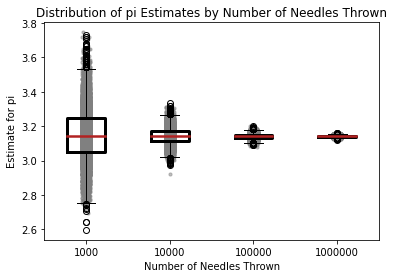

Time taken was: 647.5451016426086


In [1]:
# Box plot 

import numpy as np
import matplotlib.pyplot as plt
import time

# Define your needle counts
NEEDV = np.array([1000, 10000, 100000, 1000000], dtype=int)

# Buffon's Needle simulation parameters
t = 20
len_needle = 10
n_runs = 10000  # Number of simulations per needle count

def run_buffons_needle_simulation(num_needles):
    angles = np.random.uniform(0, np.pi, num_needles)
    positions = np.random.uniform(0, 600, num_needles)

    x1 = positions - (len_needle / 2) * np.cos(angles)
    x2 = positions + (len_needle / 2) * np.cos(angles)

    line1 = np.floor(x1 / t)
    line2 = np.floor(x2 / t)
    intersections = np.sum(line1 != line2)

    probability = intersections / num_needles
    pi_est=(2 * len_needle) / (probability * t)
    return pi_est if pi_est<4 else float('inf')

start_time=time.time()

# Run simulations and collect data
data = []
for n in NEEDV:
    estimates = [run_buffons_needle_simulation(n) for _ in range(n_runs)]
    data.append(estimates)


# Plot the box plots
boxprops = dict(linestyle='-', linewidth=3, color='k')
medianprops = dict(linestyle='-', linewidth=2.5, color='firebrick')
plt.boxplot(data, labels=NEEDV, positions=np.log10(NEEDV), boxprops=boxprops, medianprops=medianprops)

# Plot the scatter plots with filtering
for n in NEEDV:
    pi_estimates = [run_buffons_needle_simulation(n) for _ in range(n_runs)]
    # Filter out pi estimates larger than 4
    pi_estimates = [pi for pi in pi_estimates if pi <= 4]
    # Add jitter to the x-coordinates for the scatter plot
    jittered_x = np.log10([n] * len(pi_estimates)) + (np.random.rand(len(pi_estimates)) - 0.5) * 0.1
    plt.scatter(jittered_x, pi_estimates, color='gray', alpha=0.5, s=10)


# Set x-axis to log scale
plt.xticks(np.log10(NEEDV), NEEDV)
plt.xlabel('Number of Needles Thrown')
plt.ylabel('Estimate for pi')
plt.title('Distribution of pi Estimates by Number of Needles Thrown')
plt.savefig('dist_pi_esti_needles.png')
plt.show()

end_time=time.time()

print('Time taken was:',end_time-start_time)

## Mean and Error from Method 1 

Average estimate of pi: 3.1691069583626557
Standard deviation (Monte Carlo error): 0.14504138291319255
Time taken for 100 runs: 0.685704 seconds



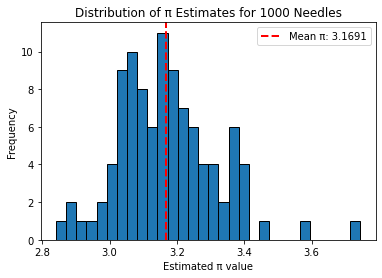

Average estimate of pi: 3.1524292052912917
Standard deviation (Monte Carlo error): 0.04512106707645979
Time taken for 100 runs: 6.910689 seconds



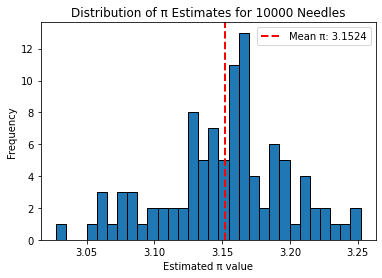

KeyboardInterrupt: 

In [ ]:
# Error for Method 1

import numpy as np
import matplotlib.pyplot as plt
import time

import os

# Create a directory to save the results
results_dir = 'method1results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Define a list of different numbers of needles
needle_counts = [1000, 10000, 100000, 1000000]

# Buffon's Needle simulation parameters
t = 20
len_needle = 10
n_runs = 100  # Number of times to run the simulation for each needle count

# Function to check if a needle intersects with a grid line
def intersects(x, angle):
    # Calculate the x-coordinates of both ends of the needle
    x1 = x - (len_needle / 2) * np.cos(angle)
    x2 = x + (len_needle / 2) * np.cos(angle)

    # Check if either end of the needle crosses a line
    line1 = np.floor(x1 / t)
    line2 = np.floor(x2 / t)

    return line1 != line2

# Function to run the simulation a single time
def run_simulation(num_needles, t, len_needle):
    intersecting = 0
    for _ in range(num_needles):
        angle = np.random.uniform(0, np.pi)
        x = np.random.uniform(0, 600)
        if intersects(x, angle):
            intersecting += 1
    probability = intersecting / num_needles
    return (2 * len_needle) / (probability * t) if probability > 0 else float('inf')

def quantify_monte_carlo_error(n_runs, num_needles, t, len_needle):
    pi_estimates = [run_simulation(num_needles, t, len_needle) for _ in range(n_runs)]
    mean_pi = np.mean(pi_estimates)
    std_dev = np.std(pi_estimates)
    print(f"Average estimate of pi: {mean_pi}")
    print(f"Standard deviation (Monte Carlo error): {std_dev}")
    return pi_estimates, mean_pi  # Add this return statement

# Iterate over the different needle counts
for num_needles in needle_counts:
    start_time = time.time()

    # Run the simulation multiple times for the current number of needles
    pi_estimates, mean_pi = quantify_monte_carlo_error(n_runs, num_needles, t, len_needle)

    end_time = time.time()

    # Print the results
    print(f'Time taken for {n_runs} runs: {end_time - start_time:.6f} seconds\n')

    # Plot the distribution of pi estimates
    plt.figure()
    plt.hist(pi_estimates, bins=30, edgecolor='black')
    plt.axvline(mean_pi, color='red', linestyle='dashed', linewidth=2, label=f'Mean π: {mean_pi:.4f}')
    plt.xlabel('Estimated π value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of π Estimates for {num_needles} Needles')
    plt.legend()
    plt.show()

    # Save the plot
    plt.savefig(f'{results_dir}/pi_distribution_method1_{num_needles}_needles.png')
    plt.close()

end_time = time.time()
print(f'Time taken: {end_time - start_time:.6f} seconds')

In [ ]:
## Need to check why it exists but I think it plots one only

In [ ]:
# Error for Method 1

import numpy as np
import matplotlib.pyplot as plt
import time

# Buffon's Needle simulation parameters
num_needles = 1000
t = 20
len_needle = 10
n_runs = 100  # Number of times to run the simulation to calculate the error

# Record start time
start_time=time.time()

# Function to check if a needle intersects with a grid line
def intersects(x, angle):
    # Calculate the x-coordinates of both ends of the needle
    x1 = x - (len_needle / 2) * np.cos(angle)
    x2 = x + (len_needle / 2) * np.cos(angle)

    # Check if either end of the needle crosses a line
    line1 = np.floor(x1 / t)
    line2 = np.floor(x2 / t)

    return line1 != line2

# Function to run the simulation a single time
def run_simulation(num_needles, t, len_needle):
    intersecting = 0
    for _ in range(num_needles):
        angle = np.random.uniform(0, np.pi)
        x = np.random.uniform(0, 600)
        if intersects(x, angle):
            intersecting += 1
    probability = intersecting / num_needles
    return (2 * len_needle) / (probability * t) if probability > 0 else float('inf')

def quantify_monte_carlo_error(n_runs, num_needles, t, len_needle):
    pi_estimates = [run_simulation(num_needles, t, len_needle) for _ in range(n_runs)]
    mean_pi = np.mean(pi_estimates)
    std_dev = np.std(pi_estimates)
    print(f"Average estimate of pi: {mean_pi}")
    print(f"Standard deviation (Monte Carlo error): {std_dev}")
    return pi_estimates, mean_pi  # Add this return statement

# Run the simulation multiple times and calculate Monte Carlo error
pi_estimates = [run_simulation(num_needles, t, len_needle) for _ in range(n_runs)]
mean_pi = np.mean(pi_estimates)
std_dev_pi = np.std(pi_estimates)

# Record end time
end_time = time.time()

# Print the estimated value of pi, mean, standard deviation, and the time taken
print(f'Mean estimated value of pi: {mean_pi:.9f}')
print(f'Standard deviation (Monte Carlo error): {std_dev_pi:.9f}')
print(f'Time taken for {n_runs} runs: {end_time - start_time:.6f} seconds')

# Optional: Plot the distribution of pi estimates
plt.hist(pi_estimates, bins=30, edgecolor='black')
plt.axvline(mean_pi, color='red', linestyle='dashed', linewidth=2, label=f'Mean π')
plt.xlabel('Estimated π value')
plt.ylabel('Frequency')
plt.title('Distribution of π Estimates Using Method 1')

plt.legend()
plt.show()

## for loop method results

## Mean and Error for Method 2

Array method containing mean and error
Average estimate of pi: 3.1412744043670946
Standard deviation (Monte Carlo error): 0.02460467753198525
Time taken for 10000 runs: 940.703529 seconds



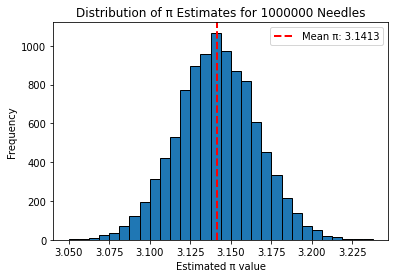

Time taken: 941.073509 seconds


In [8]:
# Error for Array Method

# Logarithmic relation found in compilation time

import numpy as np
import matplotlib.pyplot as plt
import time

import os

print('Array method containing mean and error')

# Create a directory to save the results
results_dir = 'method2_100needle'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)


# Define a list of different numbers of needles
needle_counts = [1000000]

n_runs = 10000

t = 20

len_needle = 0.5

def run_buffons_needle_simulation(num_needles, t, len_needle):
    angles = np.random.uniform(0, np.pi, num_needles)
    positions = np.random.uniform(0, 600, num_needles)

    x1 = positions - (len_needle / 2) * np.cos(angles)
    x2 = positions + (len_needle / 2) * np.cos(angles)

    line1 = np.floor(x1 / t)
    line2 = np.floor(x2 / t)
    intersections = np.sum(line1 != line2)

    probability = intersections / num_needles
    return (2 * len_needle) / (probability * t) if probability > 0 else float('inf')

def quantify_monte_carlo_error(n_runs, num_needles, t, len_needle):
    pi_estimates = [run_buffons_needle_simulation(num_needles, t, len_needle) for _ in range(n_runs)]
    mean_pi = np.mean(pi_estimates)
    std_dev = np.std(pi_estimates)
    #rel_err = np.sqrt((probability*(1-probability))/(needle_counts))
    print(f"Average estimate of pi: {mean_pi}")
    print(f"Standard deviation (Monte Carlo error): {std_dev}")
    #print(f"Relative error: {rel_err}")
    return pi_estimates, mean_pi  # Add this return statement

# Iterate over the different needle counts
for num_needles in needle_counts:
    start_time = time.time()

    # Run the simulation multiple times for the current number of needles
    pi_estimates, mean_pi = quantify_monte_carlo_error(n_runs, num_needles, t, len_needle)

    end_time = time.time()

    # Print the results
    print(f'Time taken for {n_runs} runs: {end_time - start_time:.6f} seconds\n')

    # Plot the distribution of pi estimates
    plt.figure()
    plt.hist(pi_estimates, bins=30, edgecolor='black')
    plt.axvline(mean_pi, color='red', linestyle='dashed', linewidth=2, label=f'Mean π: {mean_pi:.4f}')
    plt.xlabel('Estimated π value')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of π Estimates for {num_needles} Needles')
    plt.legend()

    # Save the plot
    plt.savefig(f'{results_dir}/pi_distribution_{num_needles}_needles.png')
    plt.show()

end_time = time.time()
print(f'Time taken: {end_time - start_time:.6f} seconds')

## Showing that time taken for my method increases logrighmicallycally 

In [ ]:
y=[0.038279,0.203113,3.238335,28.840297]
x=np.linspace(0,4,4)

#plt.plot(x,y)

#plt.show()

xx=np.floor(x)

plt.plot(x,np.log(y))
plt.show()

In [3]:
6*6*6*6*6*6

46656

## Physical simulation of the Experiment

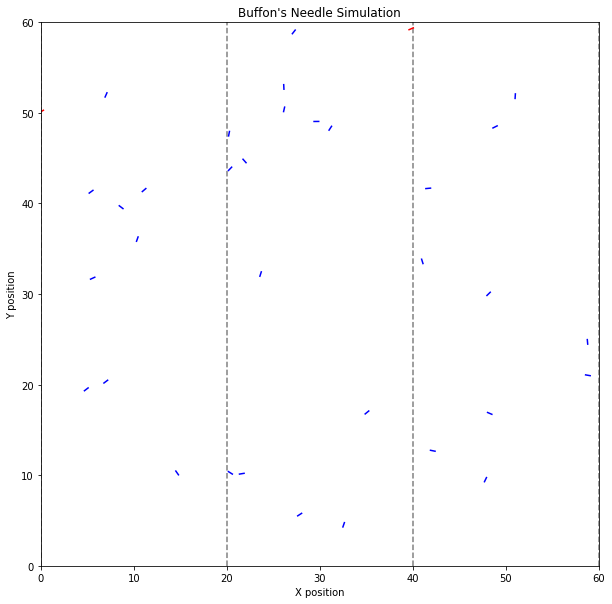

Probability: 0.05714285714285714
Num needles: 35
Estimated value of pi: 0.875000000
Time taken: 0.284691 seconds


In [6]:
import numpy as np
import time

# Buffon's Needle simulation parameters
num_needles = 35 # Increased for a larger sample size
t = 20  # Adjusted for grid spacing
len_needle = 0.5  # Adjusted to be smaller than the spacing

# Record start time
start_time = time.time()

# Generate random angles and positions
angles = np.random.uniform(0, np.pi, num_needles)
positions = np.random.uniform(0, 60, num_needles)

# Calculate x-coordinates of both ends of the needles
x1 = positions - (len_needle / 2) * np.cos(angles)
x2 = positions + (len_needle / 2) * np.cos(angles)

# Check for intersections
line1 = np.floor(x1 / t)
line2 = np.floor(x2 / t)
intersections = np.sum(line1 != line2)

# Estimate pi
probability = intersections / num_needles
pi_estimate = (2 * len_needle) / (probability * t) if probability > 0 else float('inf')

import matplotlib.pyplot as plt

# Create a plot
plt.figure(figsize=(10, 10))

# Plot grid lines
for i in range(0, 61, t):
    plt.axvline(x=i, color='grey', linestyle='--')

# Plot needles
for x, angle, line1, line2 in zip(positions, angles, line1, line2):
    x_end1 = x - (len_needle / 2) * np.cos(angle)
    x_end2 = x + (len_needle / 2) * np.cos(angle)
    y_end1 = (len_needle / 2) * np.sin(angle)
    y_end2 = -y_end1

    # Adjust y-coordinates based on angle and midpoint position
    midpoint_y = np.random.uniform(0, 60)  # Random y position for the midpoint of the needle
    y_end1 += midpoint_y
    y_end2 += midpoint_y

    # Determine color based on intersection
    color = 'r' if line1 != line2 else 'b'

    plt.plot([x_end1, x_end2], [y_end1, y_end2], color=color)

# Set plot limits and labels
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Buffon\'s Needle Simulation')
plt.savefig('visulised_board.png')

# Show the plot
plt.show()



# Record end time
end_time = time.time()


# Print the estimated value of pi and the time taken
print('Probability:', probability)
print('Num needles:', num_needles)
print(f'Estimated value of pi: {pi_estimate:.9f}')
print(f'Time taken: {end_time - start_time:.6f} seconds')